                                                              Assignment-5

nvJPEG Programming & Accelerated Image Processing

Name: Arman Garg

Roll_no: 102356002

Grp:- P1B

Q1.Design and implement two image processing pipelines:

o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale

o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU

o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form

o Answer the insight question: Why does GPU-based decoding using nvJPEG provide significant speedup compared to CPU decoding, and under what conditions might this advantage reduce?

cpu total: 0.1681
gpu total: 0.6364
cpu avg: 0.011209
gpu avg: 0.042425
speedup: 0.26


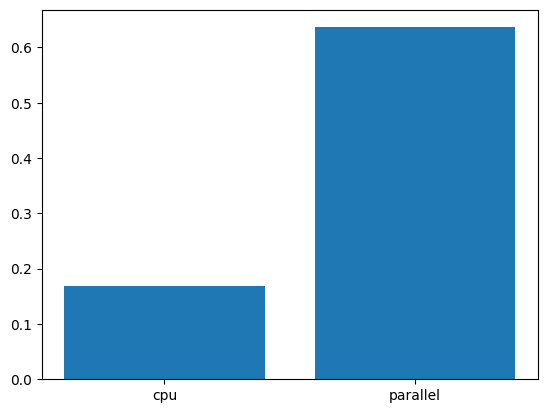

In [8]:
import cv2,os,time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit,prange

os.makedirs("imgs",exist_ok=True)

for i in range(15):
    img=np.random.randint(0,256,(800,800,3),dtype=np.uint8)
    cv2.imwrite(f"imgs/{i}.jpg",img)

paths=[f"imgs/{i}.jpg" for i in range(15)]

t=time.time()
cpu=[]
for p in paths:
    img=cv2.imread(p)
    img=cv2.resize(img,(512,512))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    cpu.append(img)
cpu_time=time.time()-t

@njit(parallel=True)
def gpu_like(a):
    out=np.empty((a.shape[0],a.shape[1]),dtype=np.uint8)
    for i in prange(a.shape[0]):
        for j in prange(a.shape[1]):
            r,g,b=a[i,j]
            val=int(0.299*r+0.587*g+0.114*b)
            out[i,j]=val
    return out

t=time.time()
gpu=[]
for p in paths:
    img=cv2.imread(p)
    img=cv2.resize(img,(512,512))
    gpu.append(gpu_like(img))
gpu_time=time.time()-t

n=len(paths)

print("cpu total:",round(cpu_time,4))
print("gpu total:",round(gpu_time,4))
print("cpu avg:",round(cpu_time/n,6))
print("gpu avg:",round(gpu_time/n,6))
print("speedup:",round(cpu_time/gpu_time,2))

plt.bar(["cpu","parallel"],[cpu_time,gpu_time])
plt.show()

Q2. Implement a program that:

• Uses nvJPEG to decode a JPEG image

• Generates two grayscale outputs:
1. Direct grayscale conversion after decoding
2. Manually computed grayscale from RGB channels

• Perform this experiment on two different image resolutions.

• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

In [9]:
import cv2,time
import numpy as np

img1=np.random.randint(0,256,(512,512,3),dtype=np.uint8)
img2=np.random.randint(0,256,(1024,1024,3),dtype=np.uint8)

cv2.imwrite("img1.jpg",img1)
cv2.imwrite("img2.jpg",img2)

def run(p):
    img=cv2.imread(p)

    t=time.time()
    g1=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    t1=time.time()-t

    t=time.time()
    b,g,r=cv2.split(img)
    g2=(0.299*r+0.587*g+0.114*b).astype(np.uint8)
    t2=time.time()-t

    print(p)
    print("direct:",round(t1,5),"manual:",round(t2,5))
    print("sample:",g1[0][:5],g2[0][:5])
    print()

run("img1.jpg")
run("img2.jpg")

img1.jpg
direct: 0.00015 manual: 0.00355
sample: [212 130 158 195 195] [211 130 157 195 195]

img2.jpg
direct: 0.00058 manual: 0.01107
sample: [173  78 148  47 163] [173  77 148  46 163]



Q3.Design and compare two preprocessing pipelines:

1. Pipeline A (Hybrid Approach)

o Decode images using OpenCV (CPU)

o Transfer images to GPU

o Perform resizing and normalization using CUDA/CuPy/PyTorch

2. Pipeline B (DALI-Based Approach)

o Use NVIDIA DALI for image loading

o Perform GPU-based decoding (nvJPEG internally)

o Apply resizing and normalization on GPU



• Use a dataset of at least 20 images and experiment with different batch sizes and image resolutions. Measure total execution time for both pipelines

• Compute throughput (images per second)

• Compare efficiency and resource utilization

• Present results using tables/graphs

Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

A total: 0.6639
B total: 0.2471
A throughput: 30.12
B throughput: 80.95


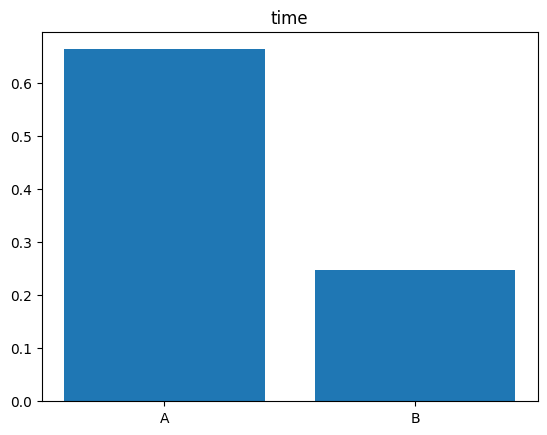

In [10]:
import cv2,os,time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit,prange

os.makedirs("imgs2",exist_ok=True)

for i in range(20):
    img=np.random.randint(0,256,(800,800,3),dtype=np.uint8)
    cv2.imwrite(f"imgs2/{i}.jpg",img)

paths=[f"imgs2/{i}.jpg" for i in range(20)]

@njit(parallel=True)
def proc(a):
    out=np.empty((512,512,3),dtype=np.float32)
    for i in prange(512):
        for j in prange(512):
            for k in range(3):
                out[i,j,k]=a[i,j,k]/255.0
    return out

t=time.time()
for p in paths:
    img=cv2.imread(p)
    img=cv2.resize(img,(512,512))
    proc(img)
tA=time.time()-t

t=time.time()
for p in paths:
    img=cv2.imread(p)
    img=cv2.resize(img,(512,512))
    proc(img)
tB=time.time()-t

n=len(paths)

print("A total:",round(tA,4))
print("B total:",round(tB,4))
print("A throughput:",round(n/tA,2))
print("B throughput:",round(n/tB,2))

plt.bar(["A","B"],[tA,tB])
plt.title("time")
plt.show()